### Transfer Learning using TensorFlow Hub

In [29]:
# tensorflow_hub's hub.KerasLayer is a Keras 2 layer, but tf.keras here is
# Keras 3, so Sequential rejects it ("Only instances of `keras.Layer` can be
# added"). This makes tf.keras resolve to tf_keras (Keras 2) instead.
# MUST be set before importing tensorflow, hence the first two lines.
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pylab as plt
import datetime

print("tf", tf.__version__, "| tf.keras ->", tf.keras.__name__)

tf 2.21.0 | tf.keras -> tensorflow.keras


In [30]:
data_dir = tf.keras.utils.get_file(
    'flower_photos',
    'https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz', 
    untar=True)

In [31]:
import pathlib
data_dir = pathlib.Path(data_dir) / 'flower_photos'


In [32]:
data_dir

PosixPath('/Users/ankit/.keras/datasets/flower_photos/flower_photos')

In [33]:
!du -sh /Users/ankit/.keras/datasets/flower_photos      # 229M — whole dataset


229M	/Users/ankit/.keras/datasets/flower_photos


In [34]:
!# size per class folder
!du -sh /Users/ankit/.keras/datasets/flower_photos/flower_photos/*

412K	/Users/ankit/.keras/datasets/flower_photos/flower_photos/LICENSE.txt
 34M	/Users/ankit/.keras/datasets/flower_photos/flower_photos/daisy
 48M	/Users/ankit/.keras/datasets/flower_photos/flower_photos/dandelion
 39M	/Users/ankit/.keras/datasets/flower_photos/flower_photos/roses
 54M	/Users/ankit/.keras/datasets/flower_photos/flower_photos/sunflowers
 54M	/Users/ankit/.keras/datasets/flower_photos/flower_photos/tulips


In [35]:
# number of images
!find /Users/ankit/.keras/datasets/flower_photos -name "*.jpg" | wc -l    # 3670

    3670


In [36]:
!ls -lrt /Users/ankit/.keras/datasets/flower_photos

total 0
drwxr-xr-x@ 8 ankit  staff  256 Feb 11  2016 flower_photos


In [37]:
!ls -lrt /Users/ankit/.keras/datasets/flower_photos/flower_photos | wc -l


       7


In [38]:
# images per class (the useful count)
!for d in /Users/ankit/.keras/datasets/flower_photos/flower_photos/*/; do echo "$(ls "$d" | wc -l)  $(basename "$d")"; done

# total images
!find /Users/ankit/.keras/datasets/flower_photos -name "*.jpg" | wc -l


     633  daisy
     898  dandelion
     641  roses
     699  sunflowers
     799  tulips
    3670


In [39]:
img_height = 224
img_width = 224
BATCH_SIZE = 128

In [40]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    str(data_dir),
    validation_split=0.2,
    subset="training",
    seed=1,
    image_size=(img_height, img_width),
    batch_size=BATCH_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    str(data_dir),
    validation_split=0.2,
    subset="validation",
    seed=1,
    image_size=(img_height, img_width),
    batch_size=BATCH_SIZE)
class_names = np.array(train_ds.class_names)
print(class_names)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
['daisy' 'dandelion' 'roses' 'sunflowers' 'tulips']


In [41]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [42]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

for image_batch, labels_batch in train_ds:
    print(image_batch.shape)
    print(labels_batch.shape)
    break

(128, 224, 224, 3)
(128,)


W0000 00:00:1786535754.223576  350306 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


### Using TensorFlow Hub

In [43]:
inception_v3 = "https://tfhub.dev/google/imagenet/inception_v3/classification/5"

classifier_model = inception_v3

IMAGE_SHAPE = (224, 224)

classifier = tf.keras.Sequential([
    hub.KerasLayer(classifier_model, input_shape=IMAGE_SHAPE+(3,))
])

labels_path = tf.keras.utils.get_file(
    'ImageNetLabels.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt')

imagenet_labels = np.array(open(labels_path).read().splitlines())

4/4 [==============================] - 2s 403ms/step
7/30 correct before fine-tuning


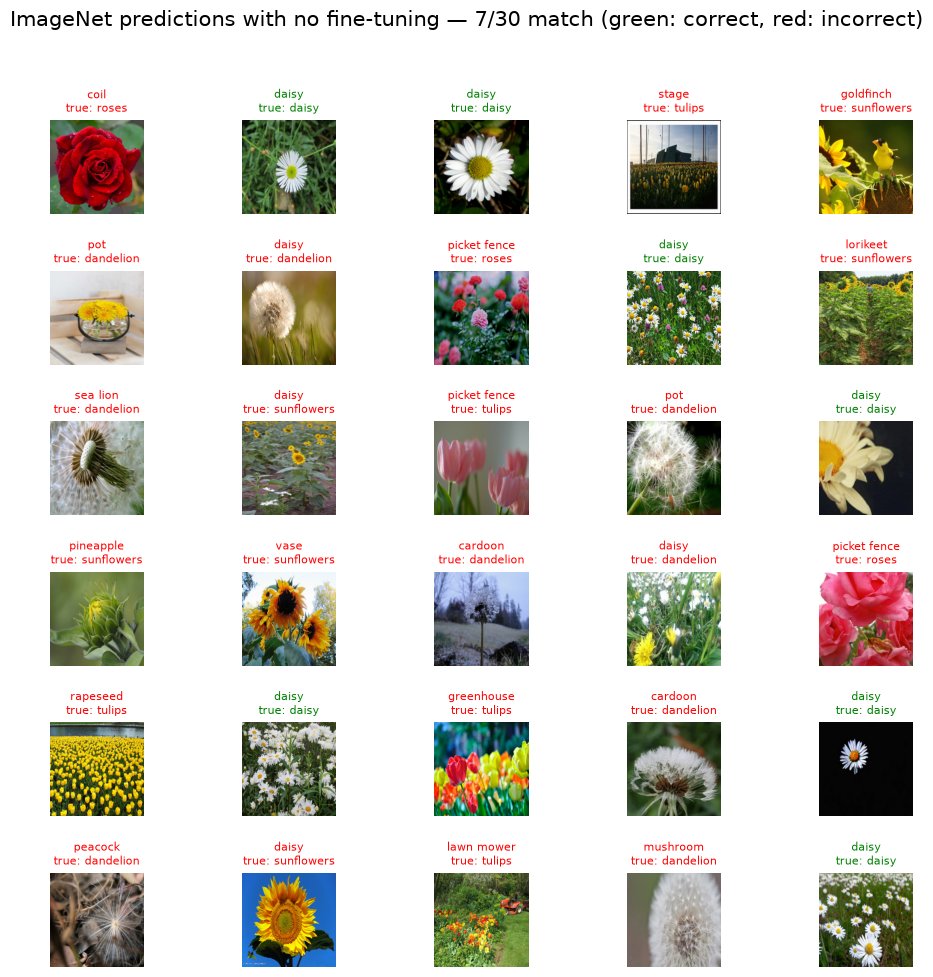

In [44]:
# Predict on `image_batch` itself, NOT on train_ds. train_ds is shuffled, so
# classifier.predict(train_ds) returns predictions in a different order than the
# `image_batch` grabbed earlier — the titles would not match the images shown.
result_batch = classifier.predict(image_batch)
predicted_class_names = imagenet_labels[tf.math.argmax(result_batch, axis=-1)]

# True flower label per image, so the titles can be colour-coded.
true_class_names = class_names[labels_batch.numpy()]

def is_correct(predicted, true):
    """ImageNet label vs flower class. Singularise ('roses' -> 'rose') and look
    for it inside the ImageNet name, so 'daisy' matches and 'coil' does not."""
    return true.rstrip('s').lower() in predicted.lower()

plt.figure(figsize=(12, 11))
plt.subplots_adjust(hspace=0.6)
for n in range(30):
    plt.subplot(6, 5, n + 1)
    plt.imshow(image_batch[n])
    ok = is_correct(predicted_class_names[n], true_class_names[n])
    plt.title(f"{predicted_class_names[n]}\ntrue: {true_class_names[n]}",
              color="green" if ok else "red", fontsize=8)
    plt.axis('off')

n_correct = sum(is_correct(p, t)
                for p, t in zip(predicted_class_names[:30], true_class_names[:30]))
_ = plt.suptitle(
    f"ImageNet predictions with no fine-tuning — {n_correct}/30 match "
    "(green: correct, red: incorrect)", fontsize=15)

# Only 'daisy' exists as a class in ImageNet-1k; dandelion, rose, sunflower and
# tulip do not. So most predictions MUST be wrong here — that is precisely the
# motivation for the fine-tuning done in the next cells.
print(f"{n_correct}/30 correct before fine-tuning")

Now, because the inception v3 model has been trained on imagenet, this means that it understands the basics of the images like shape, contour and texture of the images. So, we don't want to lose this and that's why we set `trainable=False` below. 

In [45]:
feature_extractor_model = inception_v3

feature_extractor_layer = hub.KerasLayer(
    feature_extractor_model, 
    input_shape=(224, 224, 3), 
    trainable=False # this will freeze the weights and parameters in our inception v3 model
)

In [46]:
NUM_CLASSES = len(class_names)

model = tf.keras.Sequential([
    feature_extractor_layer,
    tf.keras.layers.Dense(NUM_CLASSES) # added a fully connected layer with 5 outputs (5 classes of flowers in our dataset) in our inception v3 model
])
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_3 (KerasLayer)  (None, 1001)              23853833  
                                                                 
 dense_1 (Dense)             (None, 5)                 5010      
                                                                 
Total params: 23858843 (91.01 MB)
Trainable params: 5010 (19.57 KB)
Non-trainable params: 23853833 (91.00 MB)
_________________________________________________________________


In [47]:
pred = model(image_batch)

In [48]:
pred.shape

TensorShape([128, 5])

### Train the Model

In [49]:
NUM_EPOCHS = 10

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['acc'])

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=NUM_EPOCHS
).history

Epoch 1/10
23/23 [==============================] - 52s 2s/step - loss: 1.4335 - acc: 0.5354 - val_loss: 0.8322 - val_acc: 0.7357
Epoch 2/10
23/23 [==============================] - 61s 3s/step - loss: 0.6244 - acc: 0.7899 - val_loss: 0.6414 - val_acc: 0.7956
Epoch 3/10
23/23 [==============================] - 71s 3s/step - loss: 0.4784 - acc: 0.8389 - val_loss: 0.5782 - val_acc: 0.8188
Epoch 4/10
23/23 [==============================] - 82s 4s/step - loss: 0.4036 - acc: 0.8563 - val_loss: 0.5440 - val_acc: 0.8243
Epoch 5/10
23/23 [==============================] - 82s 4s/step - loss: 0.3550 - acc: 0.8733 - val_loss: 0.5223 - val_acc: 0.8324
Epoch 6/10
23/23 [==============================] - 73s 3s/step - loss: 0.3197 - acc: 0.8890 - val_loss: 0.5070 - val_acc: 0.8351
Epoch 7/10
23/23 [==============================] - 72s 3s/step - loss: 0.2928 - acc: 0.8965 - val_loss: 0.4959 - val_acc: 0.8351
Epoch 8/10
23/23 [==============================] - 72s 3s/step - loss: 0.2713 - acc: 0.90

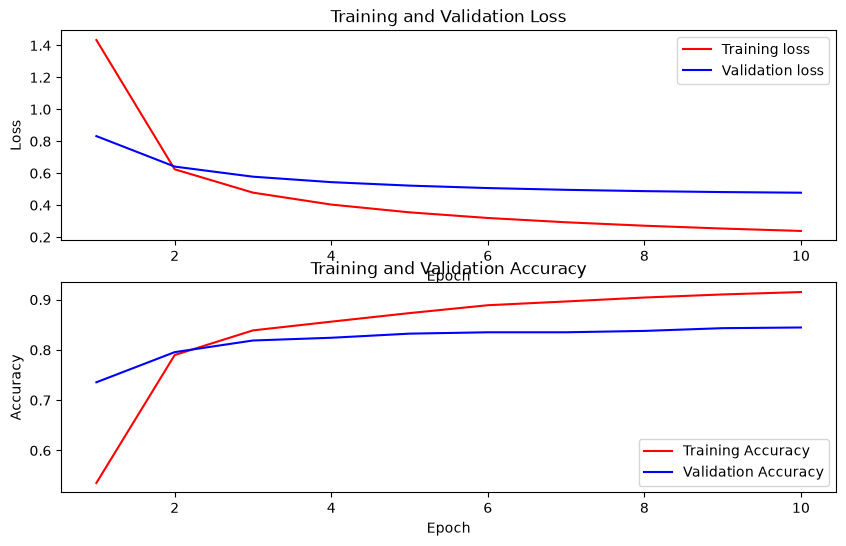

In [50]:
acc = history['acc']
val_acc = history['val_acc']
loss = history['loss']
val_loss = history['val_loss']

epochs = range(1,len(acc)+1)
fig = plt.figure(figsize=(10, 6))
fig.tight_layout()

plt.subplot(2, 1, 1)
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(epochs, acc, 'r', label='Training Accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

Now, let's take a batch of images and see how well this does on our fine-tuned model. 

### Check Predictions

In [51]:
image_batch, labels = next(iter(val_ds))
predicted_batch = model.predict(image_batch)
predicted_batch

4/4 [==============================] - 3s 562ms/step


array([[-5.1302056e+00, -6.5170914e-01,  1.8372033e+00,  3.0137709e-01,
         8.7173290e+00],
       [-5.0473185e+00, -5.0569115e+00,  3.9914761e+00,  1.6831534e+00,
         1.7397889e+00],
       [-1.9345978e-01,  4.4018836e+00, -2.2385559e+00, -1.7374725e+00,
        -9.6419972e-01],
       [ 8.1926422e+00, -4.8089528e-01, -3.7993958e+00,  1.2803732e+00,
        -3.1192079e+00],
       [-4.0715075e+00,  3.4652092e+00,  2.9749548e+00,  4.8772426e+00,
        -6.1305109e-03],
       [-7.5322866e-01, -2.9110436e+00, -2.6343298e-01,  4.5996845e-01,
         4.1992478e+00],
       [ 1.6797869e+00, -6.2745237e-01, -5.6388366e-01,  7.0897055e+00,
        -4.2352600e+00],
       [ 5.2504268e+00, -3.9719760e-01, -3.1305397e+00,  1.4169226e+00,
        -1.0950546e+00],
       [-4.5370979e+00, -5.0737457e+00,  7.1390051e-01, -1.3934651e-01,
         3.0426664e+00],
       [-1.0362229e+00,  5.7569432e-01, -1.1384990e+00,  4.9704146e+00,
        -1.7851087e+00],
       [-4.7044268e+00,  4.603

In [52]:
predicted_batch.shape

(128, 5)

In [53]:
class_names

array(['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips'],
      dtype='<U10')

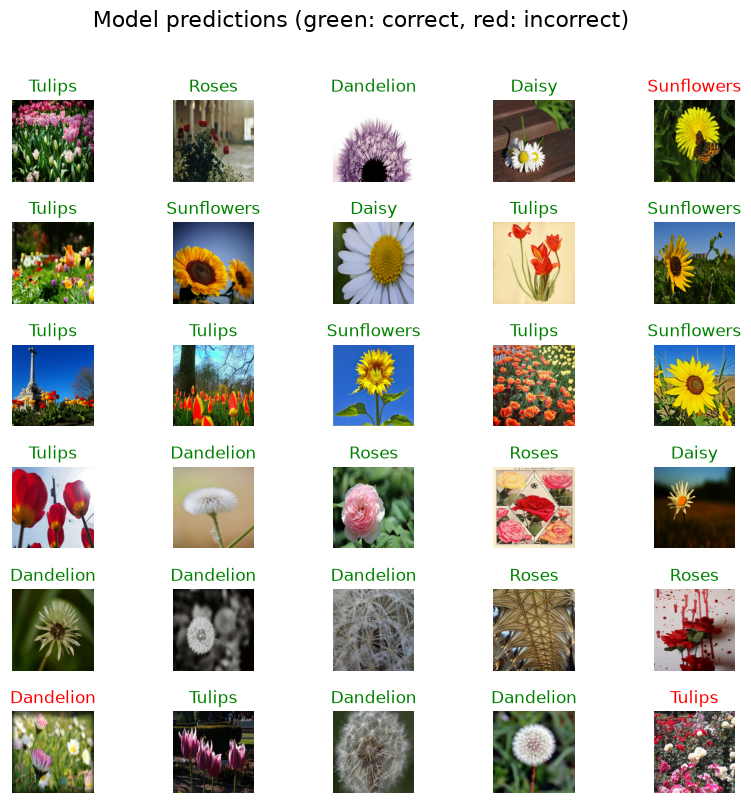

In [54]:
# tf.math.argmax returns int64 by default, but image_dataset_from_directory
# yields int32 labels, and TF will not auto-cast for ==. Ask argmax for int32
# so predicted_id[n] == labels[n] compares cleanly.
predicted_id = tf.math.argmax(predicted_batch, axis=-1, output_type=tf.int32)
predicted_label_batch = class_names[predicted_id]

plt.figure(figsize=(10,9))
plt.subplots_adjust(hspace=0.5)

for n in range(30):
    plt.subplot(6, 5, n + 1)
    plt.imshow(image_batch[n])
    color = "green" if predicted_id[n] == labels[n] else "red"
    plt.title(predicted_label_batch[n].title(), color=color)
    plt.axis('off')
_ = plt.suptitle("Model predictions (green: correct, red: incorrect)", fontsize=16)